In [ ]:
# Core for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# for math and dataframe reading
import pandas as pd
import numpy as np

import re

In [ ]:
# mounting google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
'''
Step 2 (EuroLLM): Add base prediction and comparison columns

This step prepares the dataframe for counterfactual fairness analysis by:
  (1) loading the EuroLLM results and re-parsing CEFR predictions from raw outputs,
  (2) normalizing demographic labels to match other models,
  (3) extracting each essay's base prediction,
  (4) attaching it to every variant row, and
  (5) computing two key columns: changed_vs_base (binary) and D_i (signed difference).

Encoding (unified across all models): A2=1, B1=2, B2=3, C1=4.

Like Llama, EuroLLM only produces B1 and B2 predictions on this corpus, so D_i is
restricted to {-1, 0, +1}. The methodology and downstream analyses proceed identically
to those used for Llama.
'''

print("=" * 70)
print("EUROLLM - STEP 2: ATTACHING BASE PREDICTIONS AND COMPUTING DIFFERENCES")
print("=" * 70)

# ---------------------------------------------------------------
# 2.0 Load and prepare data
# ---------------------------------------------------------------

cefr_to_int_mapping = {"A2": 1, "B1": 2, "B2": 3, "C1": 4}

df_euro = pd.read_parquet("/content/drive/MyDrive/euro_rq2_full_final.parquet")

print(f"\n[2.0] Loading EuroLLM results")
print(f"      Rows loaded: {len(df_euro):,}")
print(f"      Essays: {df_euro['essay_id'].nunique()}")

# Re-parse predictions with lenient regex to catch any edge cases
def extract_cefr_label(text):
    if text is None:
        return None
    m = re.search(r"\b(A2|B1|B2|C1)\b", str(text).upper())
    return m.group(1) if m else None

df_euro["pred_label"] = df_euro["raw_output"].apply(extract_cefr_label)
df_euro["pred_int"] = df_euro["pred_label"].map(cefr_to_int_mapping)

# Normalize occupation label spelling to match other models
for col in ["occupation_ssb_group", "occupation_ssb_group_original"]:
    if col in df_euro.columns:
        df_euro[col] = df_euro[col].replace(
            "Akademiske og profesjoner", "Akademiske profesjoner"
        )

n_unparsed = df_euro["pred_label"].isna().sum()
print(f"      Unparsed predictions: {n_unparsed}")

# Predicted label distribution
print(f"\n      Predicted label distribution:")
label_dist = df_euro["pred_label"].value_counts(dropna=False).sort_index()
for label, count in label_dist.items():
    pct = 100 * count / len(df_euro)
    label_str = str(label) if pd.notna(label) else "unparsed"
    print(f"        {label_str}: {count:>10,} ({pct:5.2f}%)")

# ---------------------------------------------------------------
# 2.1 Extract base predictions (one per essay)
# ---------------------------------------------------------------
# The "base" variant is the prediction made without any demographic
# attributes manipulated. Every essay should have exactly one base row.

base_preds_euro = (
    df_euro[df_euro["variant_type"] == "base"]
    [["essay_id", "pred_label", "pred_int"]]
    .rename(columns={"pred_label": "base_label", "pred_int": "base_int"})
)

expected_n = df_euro['essay_id'].nunique()
print(f"\n[2.1] Extracting base predictions")
print(f"      Base predictions found: {len(base_preds_euro)} (expected: {expected_n})")
if len(base_preds_euro) != expected_n:
    missing = expected_n - len(base_preds_euro)
    print(f"      WARNING: {missing} essay(s) missing a base prediction.")
else:
    print(f"      All essays have a base prediction.")

# ---------------------------------------------------------------
# 2.2 Merge base predictions onto all rows
# ---------------------------------------------------------------
# After this merge, every row (including the base row itself) has
# columns indicating its essay's base prediction. This lets us compare
# each variant against its corresponding base.

df_euro = df_euro.merge(base_preds_euro, on="essay_id", how="left")
print(f"\n[2.2] Merging base predictions onto all rows")
print(f"      Total rows after merge: {len(df_euro):,}")

# ---------------------------------------------------------------
# 2.3 Compute changed_vs_base
# ---------------------------------------------------------------
# Binary indicator: True if the variant's prediction differs from
# the base prediction for that essay. This is the core input to the
# change rate metric (Equation 4 in the methodology).

df_euro["changed_vs_base"] = (
    df_euro["pred_label"].notna()
    & df_euro["base_label"].notna()
    & (df_euro["pred_label"] != df_euro["base_label"])
)

# ---------------------------------------------------------------
# 2.4 Compute D_i (signed prediction difference)
# ---------------------------------------------------------------
# Encoding: A2=1, B1=2, B2=3, C1=4.
# D_i = pred_int (variant) - base_int.
#   D_i = +1: variant predicts a higher CEFR level than base (upgrade)
#   D_i =  0: variant agrees with base
#   D_i = -1: variant predicts a lower CEFR level than base (downgrade)
# For EuroLLM, the realized prediction range is limited to B1 (=2) and B2 (=3),
# so D_i takes values in {-1, 0, +1}.

df_euro["D_i"] = df_euro["pred_int"] - df_euro["base_int"]

# ---------------------------------------------------------------
# 2.5 Sanity checks
# ---------------------------------------------------------------
# Verify internal consistency before proceeding to downstream analysis.

print(f"\n[2.5] Running sanity checks")

mask_var = df_euro["variant_type"] == "variant"

# Check 1: changed_vs_base should equal (D_i != 0) for variant rows.
check1 = (df_euro.loc[mask_var, "changed_vs_base"]
          == (df_euro.loc[mask_var, "D_i"] != 0)).all()
assert check1, "Mismatch between changed_vs_base and D_i != 0"
print(f"      Check 1 passed: changed_vs_base equals (D_i != 0) for all variants")

# Check 2: base rows must have D_i = 0 (subtracting base from itself).
check2 = (df_euro.loc[~mask_var, "D_i"] == 0).all()
assert check2, "Base rows should have D_i = 0"
print(f"      Check 2 passed: all base rows have D_i = 0")

# ---------------------------------------------------------------
# 2.6 Summary statistics
# ---------------------------------------------------------------
# Quick overview of the resulting dataset before per-essay analysis.

df_var_euro = df_euro[mask_var]
overall_cr = df_var_euro['changed_vs_base'].mean()

print(f"\n[2.6] Summary of the prepared dataset")
print(f"      Total variant rows: {len(df_var_euro):,}")
print(f"      Variants where prediction differs from base: "
      f"{int(df_var_euro['changed_vs_base'].sum()):,}")
print(f"      Overall change rate: {overall_cr:.4f} ({100*overall_cr:.2f}%)")
print(f"      (proportion of variants where prediction shifts away from base)")

print(f"\n      D_i distribution across variants:")
print(f"      (negative = downgrade, zero = same as base, positive = upgrade)")
di_counts = df_var_euro["D_i"].value_counts().sort_index()
total = len(df_var_euro)
for d, n in di_counts.items():
    if d == 0:
        label = "same as base"
    elif d > 0:
        label = "upgrade (B1 -> B2)"
    else:
        label = "downgrade (B2 -> B1)"
    print(f"        D_i = {int(d):+d}  {label:25s}  {n:>10,}  ({100*n/total:5.2f}%)")

print(f"\n      Base prediction distribution across {expected_n} essays:")
base_dist = base_preds_euro["base_label"].value_counts().sort_index()
for label, count in base_dist.items():
    pct = 100 * count / expected_n
    print(f"        {label}: {count:>4d} essays ({pct:.1f}%)")

print(f"\n[Step 2 complete] df_euro and df_var_euro are ready for per-essay analysis.")

EUROLLM - STEP 2: ATTACHING BASE PREDICTIONS AND COMPUTING DIFFERENCES

[2.0] Loading EuroLLM results
      Rows loaded: 1,764,392
      Essays: 643
      Unparsed predictions: 0

      Predicted label distribution:
        B1:  1,320,933 (74.87%)
        B2:    443,459 (25.13%)

[2.1] Extracting base predictions
      Base predictions found: 643 (expected: 643)
      All essays have a base prediction.

[2.2] Merging base predictions onto all rows
      Total rows after merge: 1,764,392

[2.5] Running sanity checks
      Check 1 passed: changed_vs_base equals (D_i != 0) for all variants
      Check 2 passed: all base rows have D_i = 0

[2.6] Summary of the prepared dataset
      Total variant rows: 1,763,749
      Variants where prediction differs from base: 115,201
      Overall change rate: 0.0653 (6.53%)
      (proportion of variants where prediction shifts away from base)

      D_i distribution across variants:
      (negative = downgrade, zero = same as base, positive = upgrade)


Okay, so based on the numbers above here we can see that the majority of predictions, about 93.5 percent stay the same. About 4.2 percent of changes go down, while 2 go up. The model seems to only go up/down one level.

# EuroLLM - Per essay stability

EUROLLM - LEVEL 1: PER-ESSAY STABILITY ANALYSIS

[3.2] Stability classification
      Total essays analyzed: 643
      Fully stable (no prediction change across any variant): 412 (64.1%)
      Unstable (at least one variant changes the prediction): 231 (35.9%)

[3.3] Per-essay change rate distribution
      (proportion of variants that change the prediction, per essay)
      Mean:     0.0653
      Median:   0.0000
      Std dev:  0.1618
      Min:      0.0000
      25th pct: 0.0000
      75th pct: 0.0173
      Max:      0.9034

[3.4] Base prediction distribution across 643 essays
      (CEFR label predicted when no demographic perturbation is applied)
      B1:  469 essays (72.9%)
      B2:  174 essays (27.1%)

[3.5] Top 10 most unstable essays (highest change rate)
      base = base CEFR prediction
      up   = number of variants that upgrade (B1 to B2)
      down = number of variants that downgrade (B2 to B1)
      Essay  238: base=B2  change_rate=0.903  up=   0  down=2478  mean_D_i=

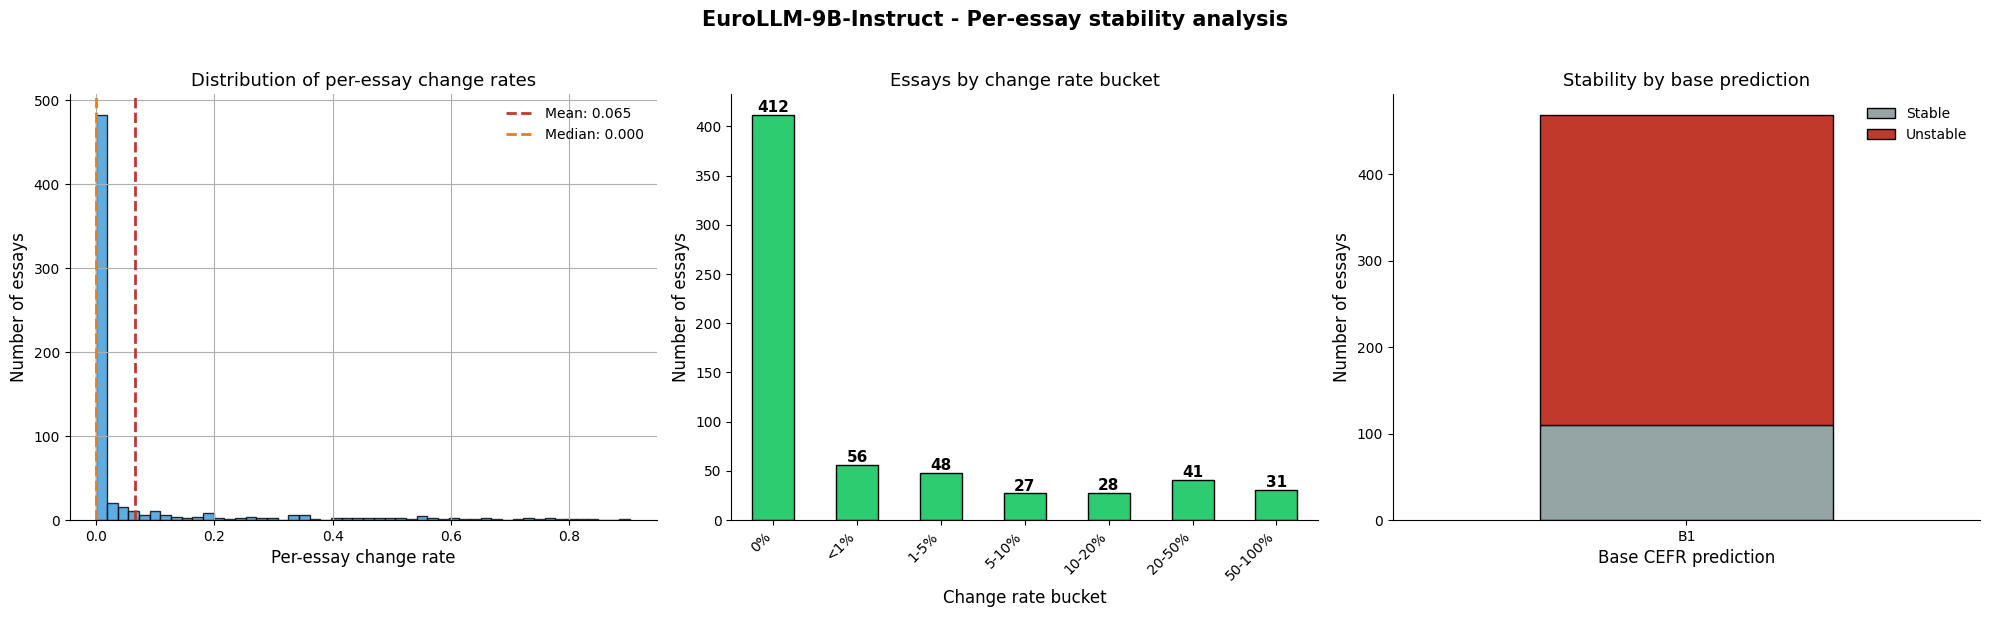


[Step 3 complete] Saved per-essay summary CSV and figure.
                  Output: essay_summary_euro (n=643 rows)


In [ ]:
'''
Step 3 (EuroLLM): Per-essay stability analysis (Level 1)

This step aggregates variant-level predictions up to the essay level to characterize
how stable each essay's CEFR prediction is under demographic perturbation. Each essay
in the factorial design has ~2,744 variants (one per demographic combination), and we
ask: for how many of those variants does the prediction differ from the base?

The output classifies essays into:
  - Fully stable: prediction never changes under any perturbation
  - Unstable: prediction changes for at least one variant

Per-essay statistics computed:
  - change_rate: proportion of variants where prediction differs from base
  - mean_D_i:    average signed difference (negative = downgrade, positive = upgrade)
  - n_up, n_down: count of upgrades/downgrades among variants
'''

print("=" * 70)
print("EUROLLM - LEVEL 1: PER-ESSAY STABILITY ANALYSIS")
print("=" * 70)

# ---------------------------------------------------------------
# 3.1 Filter to variant rows and aggregate per essay
# ---------------------------------------------------------------
# We exclude base rows from this analysis since the base is the reference
# point against which all variants are compared.

df_var_euro = df_euro[df_euro["variant_type"] == "variant"].copy()

# Sanity check carried over from Step 2 — confirm internal consistency
assert (df_var_euro["changed_vs_base"] == (df_var_euro["D_i"] != 0)).all(), \
    "Mismatch between changed_vs_base and D_i != 0 — check upstream construction"

essay_summary_euro = (
    df_var_euro.groupby("essay_id")
    .agg(
        base_label=("base_label", "first"),
        base_int=("base_int", "first"),
        n_variants=("changed_vs_base", "size"),
        n_changed=("changed_vs_base", "sum"),
        change_rate=("changed_vs_base", "mean"),
        mean_D_i=("D_i", "mean"),
        n_up=("D_i", lambda s: (s > 0).sum()),
        n_down=("D_i", lambda s: (s < 0).sum()),
        n_unique_labels=("pred_label", "nunique"),
    )
    .reset_index()
)

# An essay is "stable" if all its variants produce the same predicted label.
essay_summary_euro["stable"] = essay_summary_euro["n_unique_labels"] == 1

# ---------------------------------------------------------------
# 3.2 High-level stability counts
# ---------------------------------------------------------------

n_total = len(essay_summary_euro)
n_stable = essay_summary_euro["stable"].sum()
n_unstable = n_total - n_stable

print(f"\n[3.2] Stability classification")
print(f"      Total essays analyzed: {n_total}")
print(f"      Fully stable (no prediction change across any variant): "
      f"{n_stable} ({100*n_stable/n_total:.1f}%)")
print(f"      Unstable (at least one variant changes the prediction): "
      f"{n_unstable} ({100*n_unstable/n_total:.1f}%)")

# ---------------------------------------------------------------
# 3.3 Distribution of per-essay change rates
# ---------------------------------------------------------------
# The change rate per essay is the proportion of its ~2,744 variants
# that produce a different prediction from the base. We expect a
# bimodal-ish distribution: most essays are perfectly stable (CR=0)
# and the unstable ones span a range from near-zero to near-one.

print(f"\n[3.3] Per-essay change rate distribution")
print(f"      (proportion of variants that change the prediction, per essay)")
desc = essay_summary_euro["change_rate"].describe()
print(f"      Mean:     {desc['mean']:.4f}")
print(f"      Median:   {desc['50%']:.4f}")
print(f"      Std dev:  {desc['std']:.4f}")
print(f"      Min:      {desc['min']:.4f}")
print(f"      25th pct: {desc['25%']:.4f}")
print(f"      75th pct: {desc['75%']:.4f}")
print(f"      Max:      {desc['max']:.4f}")

# ---------------------------------------------------------------
# 3.4 Base prediction distribution
# ---------------------------------------------------------------

print(f"\n[3.4] Base prediction distribution across {n_total} essays")
print(f"      (CEFR label predicted when no demographic perturbation is applied)")
base_dist = essay_summary_euro["base_label"].value_counts().sort_index()
for label, count in base_dist.items():
    pct = 100 * count / n_total
    print(f"      {label}: {count:>4d} essays ({pct:.1f}%)")

# ---------------------------------------------------------------
# 3.5 Top 10 most unstable essays
# ---------------------------------------------------------------
# These are the essays where the prediction changes for the highest proportion
# of demographic variants. The directional split (n_up vs n_down) reveals
# whether changes go consistently in one direction or are bidirectional.

print(f"\n[3.5] Top 10 most unstable essays (highest change rate)")
print(f"      base = base CEFR prediction")
print(f"      up   = number of variants that upgrade (B1 to B2)")
print(f"      down = number of variants that downgrade (B2 to B1)")

top_unstable = essay_summary_euro.sort_values("change_rate", ascending=False).head(10)
for _, row in top_unstable.iterrows():
    print(f"      Essay {int(row['essay_id']):>4d}: base={row['base_label']}  "
          f"change_rate={row['change_rate']:.3f}  "
          f"up={int(row['n_up']):>4d}  down={int(row['n_down']):>4d}  "
          f"mean_D_i={row['mean_D_i']:+.3f}")

# ---------------------------------------------------------------
# 3.6 Change rate buckets
# ---------------------------------------------------------------
# Discretizing the change rate into buckets makes the distributional shape easier
# to read. Note: the lowest bin separates truly stable essays (CR exactly 0) from
# near-stable essays (changes on fewer than 1% of variants).

bins = [-0.0001, 0.0001, 0.01, 0.05, 0.10, 0.20, 0.50, 1.01]
labels_bucket = ["0%", "<1%", "1-5%", "5-10%", "10-20%", "20-50%", "50-100%"]
essay_summary_euro["cr_bucket"] = pd.cut(
    essay_summary_euro["change_rate"], bins=bins, labels=labels_bucket, right=False
)

print(f"\n[3.6] Change rate buckets")
print(f"      Distribution of essays by severity of instability")
bucket_counts = essay_summary_euro["cr_bucket"].value_counts().sort_index()
for bucket, count in bucket_counts.items():
    pct = 100 * count / n_total
    print(f"      {str(bucket):>10s}:  {count:>4d} essays ({pct:5.1f}%)")

# ---------------------------------------------------------------
# 3.7 Stability rate by base prediction
# ---------------------------------------------------------------
# Compares how often B1-base vs B2-base essays are unstable. A meaningful
# asymmetry here would suggest the model is more confident about one class
# than the other.

print(f"\n[3.7] Stability rate by base prediction")
stability_by_base = (
    essay_summary_euro.groupby("base_label")["stable"]
    .agg(["sum", "count"])
)
stability_by_base["stable_rate"] = stability_by_base["sum"] / stability_by_base["count"]
for label, row in stability_by_base.iterrows():
    print(f"      {label}: {int(row['sum']):>4d}/{int(row['count']):<4d} stable "
          f"({100*row['stable_rate']:.1f}%) -- "
          f"{int(row['count']) - int(row['sum'])} unstable "
          f"({100*(1 - row['stable_rate']):.1f}%)")

# ---------------------------------------------------------------
# 3.8 Visualizations
# ---------------------------------------------------------------
# Three-panel figure summarizing the per-essay stability findings:
#   Panel 1: Histogram of change rates (with mean/median markers)
#   Panel 2: Bar chart of essays per change rate bucket
#   Panel 3: Stacked bar of stable vs unstable, by base prediction

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: Histogram
ax = axes[0]
essay_summary_euro["change_rate"].hist(
    bins=50, ax=ax, color="#3498db", edgecolor="black", alpha=0.8
)
ax.axvline(
    essay_summary_euro["change_rate"].mean(), color="#c0392b",
    linestyle="--", linewidth=2,
    label=f"Mean: {essay_summary_euro['change_rate'].mean():.3f}"
)
ax.axvline(
    essay_summary_euro["change_rate"].median(), color="#e67e22",
    linestyle="--", linewidth=2,
    label=f"Median: {essay_summary_euro['change_rate'].median():.3f}"
)
ax.set_xlabel("Per-essay change rate", fontsize=12)
ax.set_ylabel("Number of essays", fontsize=12)
ax.set_title("Distribution of per-essay change rates", fontsize=13)
ax.legend(fontsize=10, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel 2: Buckets
ax = axes[1]
bucket_counts.plot(kind="bar", ax=ax, color="#2ecc71", edgecolor="black")
for j, (_, n) in enumerate(bucket_counts.items()):
    ax.text(j, n + 3, str(n), ha="center", fontsize=11, fontweight="bold")
ax.set_xlabel("Change rate bucket", fontsize=12)
ax.set_ylabel("Number of essays", fontsize=12)
ax.set_title("Essays by change rate bucket", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel 3: Stability by base
ax = axes[2]
stability_plot = essay_summary_euro.groupby(["base_label", "stable"]).size().unstack(fill_value=0)
# Ensure both columns exist even if one is empty
for col in [True, False]:
    if col not in stability_plot.columns:
        stability_plot[col] = 0
stability_plot = stability_plot[[True, False]]
stability_plot.columns = ["Stable", "Unstable"]
stability_plot.plot(
    kind="bar", stacked=True, ax=ax,
    color=["#95a5a6", "#c0392b"], edgecolor="black"
)
ax.set_xlabel("Base CEFR prediction", fontsize=12)
ax.set_ylabel("Number of essays", fontsize=12)
ax.set_title("Stability by base prediction", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(fontsize=10, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.suptitle(
    "EuroLLM-9B-Instruct - Per-essay stability analysis",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/euro_rq2_step3_per_essay.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

# ---------------------------------------------------------------
# 3.9 Save summary
# ---------------------------------------------------------------

essay_summary_euro.to_csv(
    "/content/drive/MyDrive/euro_rq2_essay_summary.csv", index=False
)
print(f"\n[Step 3 complete] Saved per-essay summary CSV and figure.")
print(f"                  Output: essay_summary_euro (n={n_total} rows)")

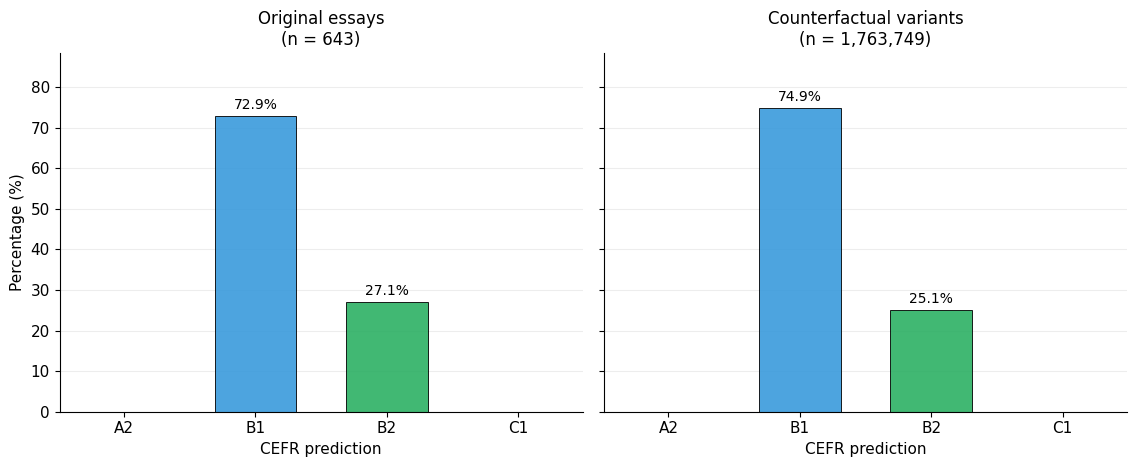

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ---------------------------------------------------------------
# Compute distributions
# ---------------------------------------------------------------

cefr_order = ["A2", "B1", "B2", "C1"]

# Consistent color per CEFR level across all model figures.
# A2 and C1 are muted because they are rarely or never predicted by Llama/EuroLLM;
# B1 and B2 are saturated as they are the realized prediction space.
cefr_colors = {
    "A2": "#bdc3c7",
    "B1": "#3498db",
    "B2": "#27ae60",
    "C1": "#bdc3c7",
}

base = df_euro[df_euro["variant_type"] == "base"]["pred_label"]
variants = df_var_euro["pred_label"]

base_counts = base.value_counts().reindex(cefr_order, fill_value=0)
variant_counts = variants.value_counts().reindex(cefr_order, fill_value=0)

base_pct = base_counts / base_counts.sum() * 100
variant_pct = variant_counts / variant_counts.sum() * 100

# ---------------------------------------------------------------
# Plot
# ---------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), sharey=True)

plot_specs = [
    (axes[0], base_pct, base_counts, "Original essays", "Percentage of essays"),
    (axes[1], variant_pct, variant_counts, "Counterfactual variants", "Percentage of variants"),
]

ymax = max(base_pct.max(), variant_pct.max()) * 1.18

for ax, pct, counts, title, ylabel in plot_specs:
    colors = [cefr_colors[lvl] for lvl in cefr_order]
    bars = ax.bar(
        cefr_order,
        pct.values,
        color=colors,
        edgecolor="black",
        linewidth=0.7,
        width=0.62,
        alpha=0.88
    )

    for bar, p, c in zip(bars, pct.values, counts.values):
        if c > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                f"{p:.1f}%",
                ha="center",
                va="bottom",
                fontsize=10
            )

    ax.set_title(f"{title}\n(n = {int(counts.sum()):,})")
    ax.set_xlabel("CEFR prediction")
    ax.set_ylim(0, ymax)
    ax.grid(axis="y", alpha=0.22)
    ax.set_axisbelow(True)

axes[0].set_ylabel("Percentage (%)")
axes[1].set_ylabel("")

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/eurollm_thesis_fig_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

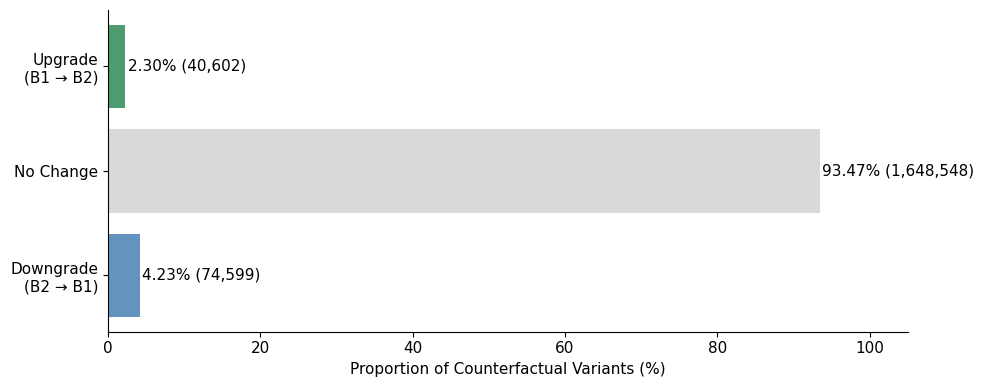

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Downgrade\n(B2 → B1)', 'No Change', 'Upgrade\n(B1 → B2)']

# Compute directly from your data for accuracy
n_down = (df_var_euro["D_i"] < 0).sum()
n_same = (df_var_euro["D_i"] == 0).sum()
n_up = (df_var_euro["D_i"] > 0).sum()
total = len(df_var_euro)

counts = [int(n_down), int(n_same), int(n_up)]
proportions = [100 * n_down / total, 100 * n_same / total, 100 * n_up / total]
colors = ['steelblue', 'lightgrey', 'seagreen']

fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.barh(labels, proportions, color=colors, alpha=0.85)

for bar, prop, count in zip(bars, proportions, counts):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f'{prop:.2f}% ({count:,})',
            va='center',
            fontsize=11)

ax.set_xlabel('Proportion of Counterfactual Variants (%)', fontsize=11)
ax.set_xlim(0, 105)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/eurollm_exp2_direction.png', dpi=300, bbox_inches='tight')
plt.show()

# EuroLLM - Change rate per demographic attribute

EUROLLM — LEVEL 2: MARGINAL CHANGE RATE (CR_g) PER DEMOGRAPHIC VALUE

gender:
  mann                             57915/882023  CR=0.0657  ███
  kvinne                           57286/881726  CR=0.0650  ███
  ──────────────────────────────────────────────────────────────────
  → Range: 0.0650 (kvinne) to 0.0657 (mann)
  → Spread: 0.0007 absolute, 1.1% relative
  → Most destabilizing value: 'mann' (CR=0.0657, +0.5% vs overall mean)
  → Most stabilizing value:   'kvinne' (CR=0.0650, -0.5% vs overall mean)
  → Interpretation: negligible spread — this variable barely affects predictions

age_group:
  Under 25                         31661/440980  CR=0.0718  ████
  55 og eldre                      28214/441092  CR=0.0640  ███
  25–39                            27757/440678  CR=0.0630  ███
  40–54                            27569/440999  CR=0.0625  ███
  ──────────────────────────────────────────────────────────────────
  → Range: 0.0625 (40–54) to 0.0718 (Under 25)
  → Spread: 0.0093 absolut

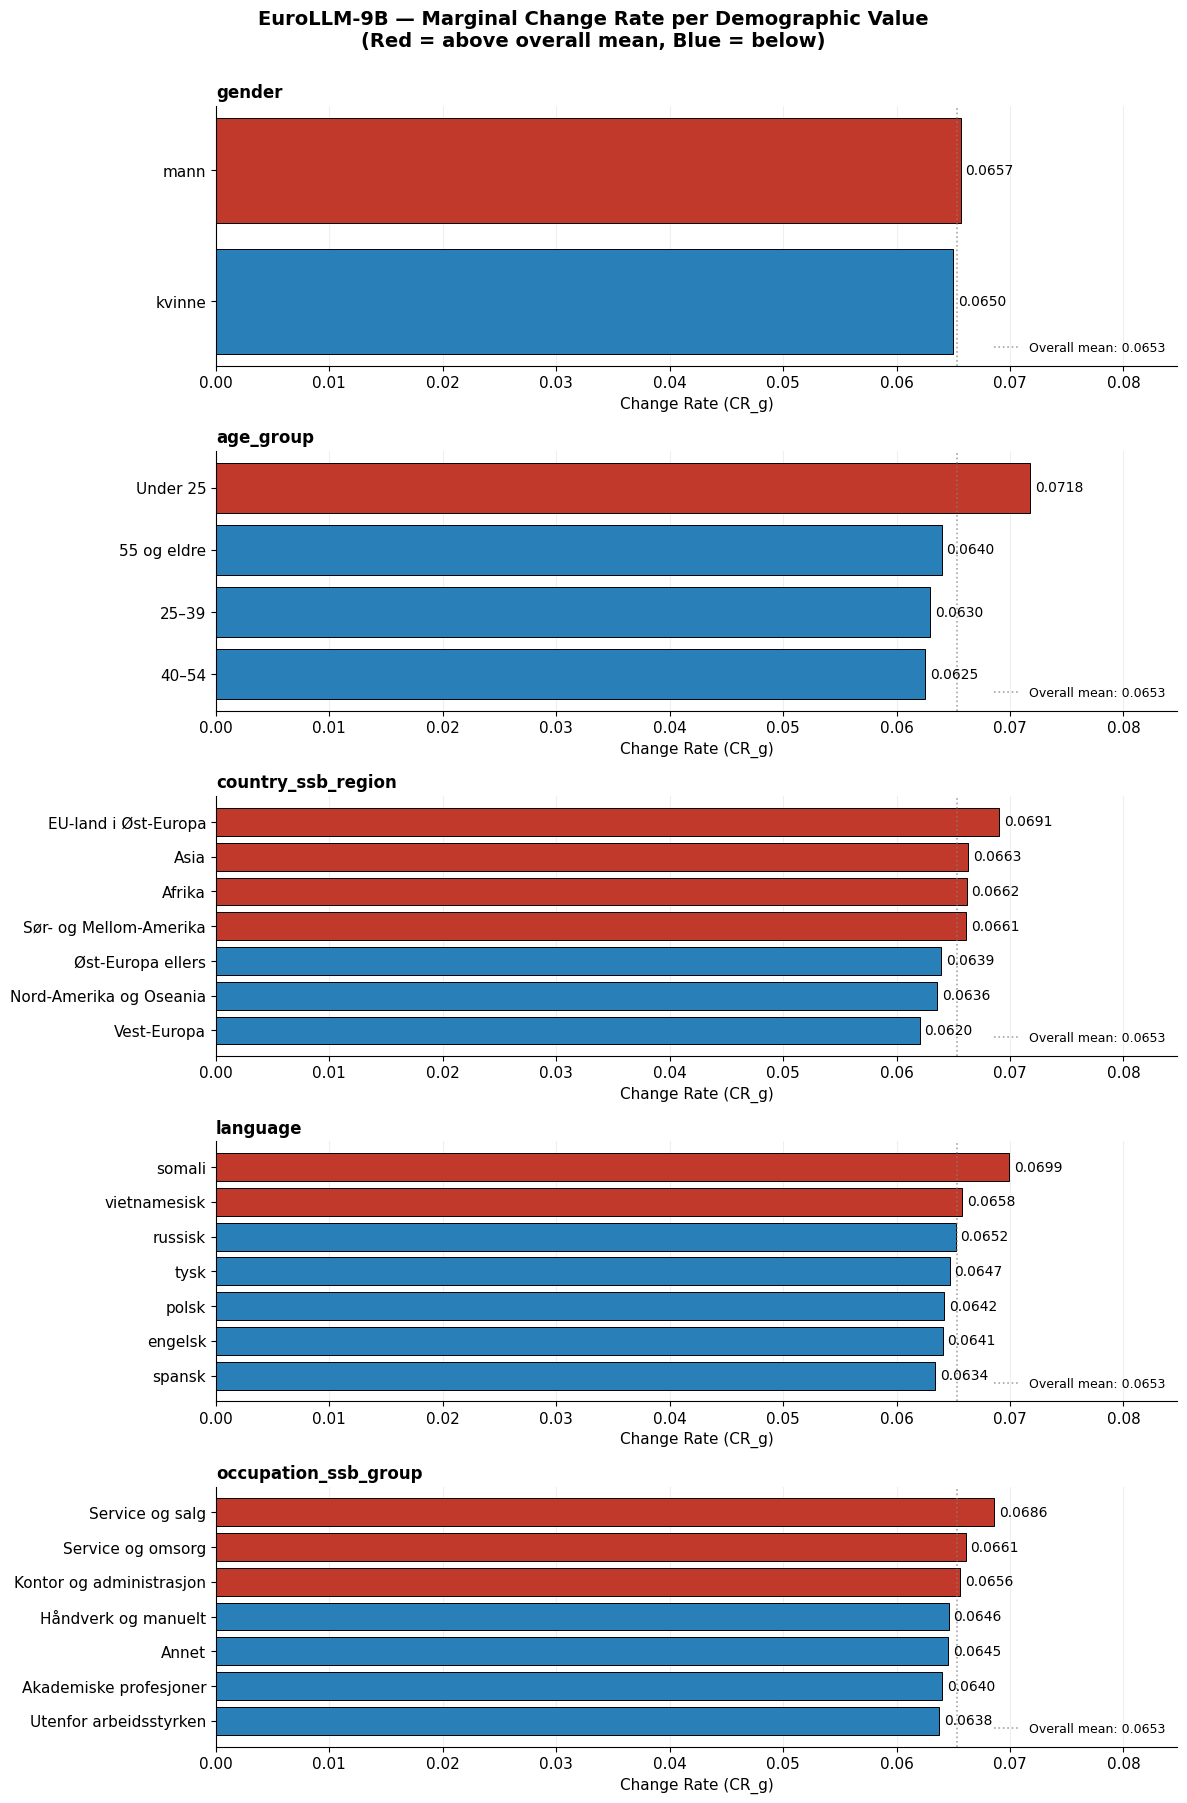

Saved CR_g results and plot


In [ ]:
print("=" * 70)
print("EUROLLM — LEVEL 2: MARGINAL CHANGE RATE (CR_g) PER DEMOGRAPHIC VALUE")
print("=" * 70)

cr_results_euro = []
overall_cr_euro = df_var_euro["changed_vs_base"].mean()

for var in ["gender", "age_group", "country_ssb_region", "language", "occupation_ssb_group"]:
    print(f"\n{var}:")
    grp = df_var_euro.groupby(var)["changed_vs_base"].agg(["size", "sum", "mean"])
    grp.columns = ["n_variants", "n_changed", "CR_g"]
    grp = grp.sort_values("CR_g", ascending=False)
    for val, row in grp.iterrows():
        bar = "█" * int(round(row["CR_g"] * 50))
        print(f"  {str(val)[:30]:30s}  {int(row['n_changed']):>6d}/{int(row['n_variants']):<6d}  "
              f"CR={row['CR_g']:.4f}  {bar}")
        cr_results_euro.append({
            "variable": var, "value": val,
            "n_variants": int(row["n_variants"]),
            "n_changed": int(row["n_changed"]),
            "CR_g": row["CR_g"],
        })

    # Interpretation block
    cr_max = grp["CR_g"].max()
    cr_min = grp["CR_g"].min()
    val_max = grp["CR_g"].idxmax()
    val_min = grp["CR_g"].idxmin()
    spread = cr_max - cr_min
    relative_spread = (spread / cr_min) * 100 if cr_min > 0 else 0

    print(f"  {'─' * 66}")
    print(f"  → Range: {cr_min:.4f} ({val_min}) to {cr_max:.4f} ({val_max})")
    print(f"  → Spread: {spread:.4f} absolute, {relative_spread:.1f}% relative")
    print(f"  → Most destabilizing value: '{val_max}' (CR={cr_max:.4f}, "
          f"{(cr_max/overall_cr_euro - 1)*100:+.1f}% vs overall mean)")
    print(f"  → Most stabilizing value:   '{val_min}' (CR={cr_min:.4f}, "
          f"{(cr_min/overall_cr_euro - 1)*100:+.1f}% vs overall mean)")

    # Qualitative magnitude tag
    if relative_spread < 2:
        tag = "negligible spread — this variable barely affects predictions"
    elif relative_spread < 6:
        tag = "small spread — modest variation across values"
    elif relative_spread < 12:
        tag = "moderate spread — notable variation across values"
    else:
        tag = "large spread — substantial variation across values"
    print(f"  → Interpretation: {tag}")

df_cr_euro = pd.DataFrame(cr_results_euro)

# Plotting
variables = ["gender", "age_group", "country_ssb_region", "language", "occupation_ssb_group"]
xmax = df_cr_euro["CR_g"].max() * 1.18

fig, axes = plt.subplots(len(variables), 1, figsize=(12, 18))

for idx, var in enumerate(variables):
    ax = axes[idx]
    subset = df_cr_euro[df_cr_euro["variable"] == var].sort_values("CR_g", ascending=True)

    bar_colors = ["#c0392b" if cr > overall_cr_euro else "#2980b9" for cr in subset["CR_g"]]
    bars = ax.barh(subset["value"], subset["CR_g"], color=bar_colors, edgecolor="black", linewidth=0.7)

    for bar, cr in zip(bars, subset["CR_g"]):
        ax.text(bar.get_width() + xmax * 0.005, bar.get_y() + bar.get_height() / 2,
                f"{cr:.4f}", va="center", fontsize=10)

    ax.axvline(overall_cr_euro, color="gray", linestyle=":", linewidth=1.2, alpha=0.7,
               label=f"Overall mean: {overall_cr_euro:.4f}")

    ax.set_xlim(0, xmax)
    ax.set_xlabel("Change Rate (CR_g)", fontsize=11)
    ax.set_title(f"{var}", fontsize=12, fontweight="bold", loc="left")
    ax.legend(fontsize=9, loc="lower right", frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="-", alpha=0.2)
    ax.set_axisbelow(True)

plt.suptitle("EuroLLM-9B — Marginal Change Rate per Demographic Value\n"
             "(Red = above overall mean, Blue = below)",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/euro_rq2_step4_cr_by_group.png", dpi=150, bbox_inches="tight")
plt.show()

df_cr_euro.to_csv("/content/drive/MyDrive/euro_rq2_cr_by_group.csv", index=False)
print("Saved CR_g results and plot")

# EUROLLM — LEVEL 2: PAIRED WILCOXON SIGNED-RANK TESTS with Benjamini-Hochberg FDR correction

EUROLLM — LEVEL 2: PAIRED WILCOXON SIGNED-RANK TESTS
With Benjamini-Hochberg FDR correction

gender:
      kvinne                        Δ=-0.0119  p=0.4502  r=0.066 [negligible]    (n=643, n*=217)
      mann                          Δ=-0.0266  p=0.0554  r=0.187 [small]         (n=643, n*=220)
  → 0/2 values show significant shift after BH correction

age_group:
      40–54                         Δ=-0.0022  p=0.8492  r=0.015 [negligible]    (n=643, n*=201)
      25–39                         Δ=-0.0100  p=0.5740  r=0.051 [negligible]    (n=643, n*=202)
      55 og eldre                   Δ=-0.0211  p=0.1217  r=0.147 [small]         (n=643, n*=205)
  *** Under 25                      Δ=-0.0438  p=0.0004  r=0.350 [medium]        (n=643, n*=205)
  → 1/4 values show significant shift after BH correction
  → Strongest downgrade bias: 'Under 25' (Δ=-0.0438, r=0.350, medium)

country_ssb_region:
      Nord-Amerika og Oseania       Δ=-0.0065  p=0.7818  r=0.027 [negligible]    (n=643, n*=186)
 

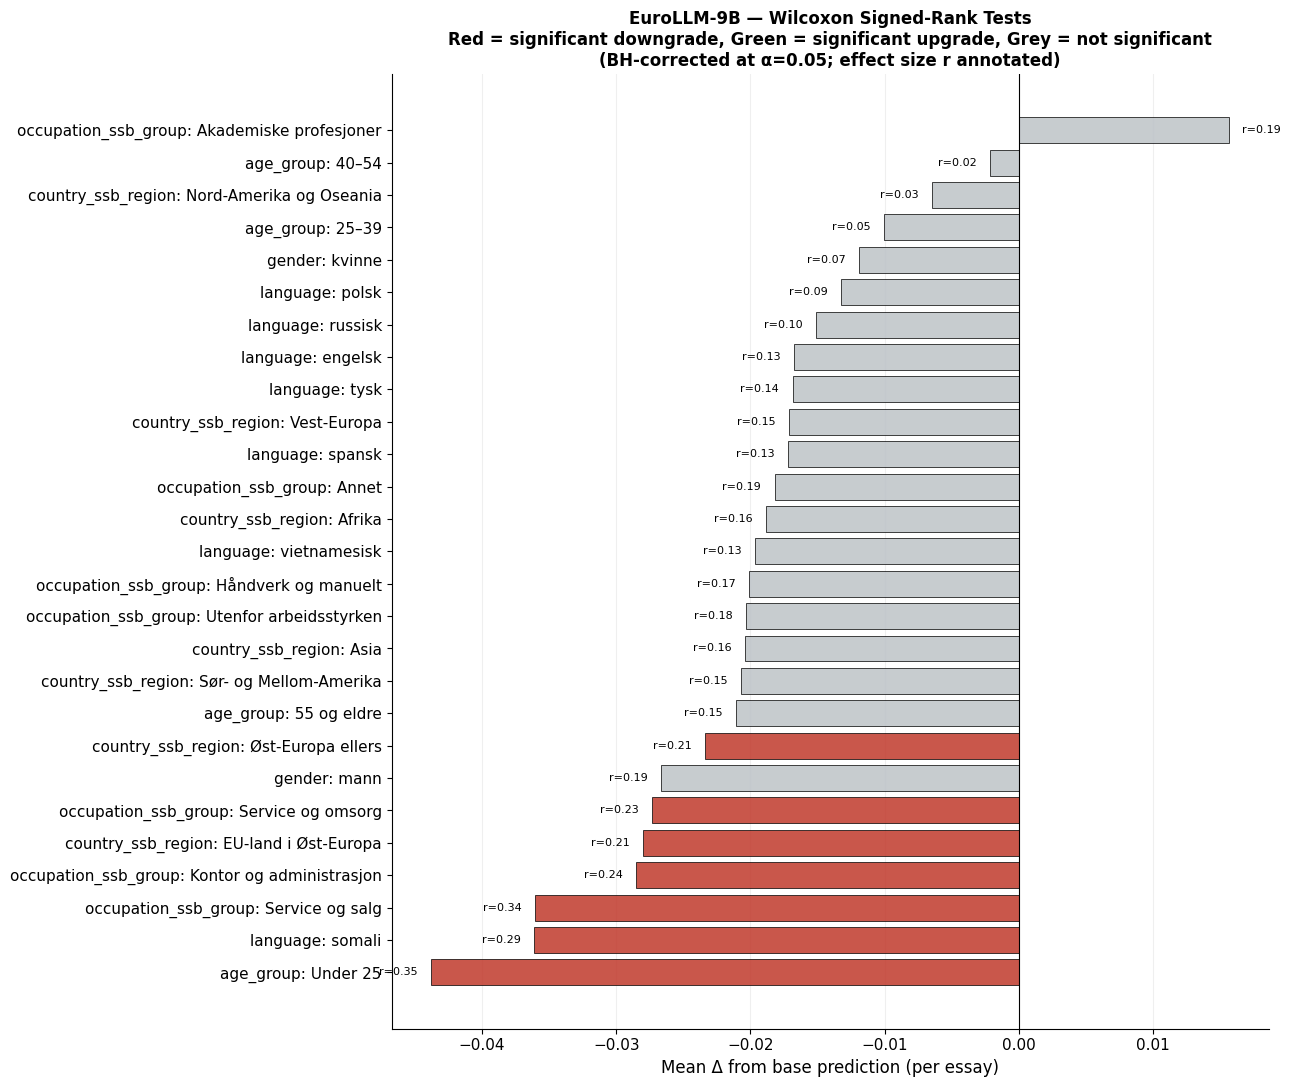


Saved 27 test results and plot


In [ ]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

print("=" * 70)
print("EUROLLM — LEVEL 2: PAIRED WILCOXON SIGNED-RANK TESTS")
print("With Benjamini-Hochberg FDR correction")
print("=" * 70)

all_tests_euro = []

for var in ["gender", "age_group", "country_ssb_region", "language", "occupation_ssb_group"]:
    values = sorted(df_euro[var].unique())

    essay_means = (
        df_euro.groupby(["essay_id", var])["pred_int"]
        .mean()
        .unstack(fill_value=None)
    )

    base_per_essay = (
        df_euro[df_euro["variant_type"] == "base"]
        .set_index("essay_id")["pred_int"]
    )

    for val in values:
        if val not in essay_means.columns:
            continue

        paired = pd.DataFrame({
            "base": base_per_essay,
            "val_mean": essay_means[val],
        }).dropna()

        diff = paired["val_mean"] - paired["base"]
        nonzero = diff[diff != 0]
        n_star = len(nonzero)

        if n_star < 10:
            all_tests_euro.append({
                "variable": var, "value": val,
                "n_essays": len(paired), "n_nonzero": n_star,
                "mean_diff": diff.mean(), "stat": None, "p_value": None,
                "r_effect": None,
            })
            continue

        stat, p = wilcoxon(nonzero)
        # Rank-biserial correlation (Kerby 2014 / Cureton 1956)
        # scipy.wilcoxon returns W = min(T+, T-) by default
        # r = |4W / (N*(N*+1)) - 1|, equivalent to your Equation 9
        r = abs(4 * stat / (n_star * (n_star + 1)) - 1)

        all_tests_euro.append({
            "variable": var, "value": val,
            "n_essays": len(paired), "n_nonzero": n_star,
            "mean_diff": diff.mean(), "stat": stat, "p_value": p,
            "r_effect": r,
        })

df_tests_euro = pd.DataFrame(all_tests_euro)

valid_mask = df_tests_euro["p_value"].notna()
if valid_mask.sum() > 0:
    reject, pvals_corrected, _, _ = multipletests(
        df_tests_euro.loc[valid_mask, "p_value"], method="fdr_bh", alpha=0.05
    )
    df_tests_euro.loc[valid_mask, "p_corrected"] = pvals_corrected
    df_tests_euro.loc[valid_mask, "significant"] = reject

# Effect size interpretation per Cohen (1988)
def effect_label(r):
    if pd.isna(r):
        return "n/a"
    elif r >= 0.50:
        return "large"
    elif r >= 0.30:
        return "medium"
    elif r >= 0.10:
        return "small"
    else:
        return "negligible"

df_tests_euro["effect_size"] = df_tests_euro["r_effect"].apply(effect_label)

# Printed output
for var in ["gender", "age_group", "country_ssb_region", "language", "occupation_ssb_group"]:
    subset = df_tests_euro[df_tests_euro["variable"] == var].sort_values("mean_diff", ascending=False)
    print(f"\n{var}:")
    for _, row in subset.iterrows():
        sig = "***" if row.get("significant") else "   "
        p_str = f"p={row['p_corrected']:.4f}" if pd.notna(row.get("p_corrected")) else "p=n/a    "
        r_str = f"r={row['r_effect']:.3f}" if pd.notna(row.get("r_effect")) else "r=n/a "
        eff_str = f"[{row['effect_size']}]"
        print(f"  {sig} {str(row['value'])[:28]:28s}  Δ={row['mean_diff']:+.4f}  "
              f"{p_str}  {r_str} {eff_str:14s}  (n={int(row['n_essays'])}, n*={int(row['n_nonzero'])})")

    # Per-variable summary
    sig_count = subset["significant"].sum() if "significant" in subset.columns else 0
    n_total = len(subset)
    print(f"  → {sig_count}/{n_total} values show significant shift after BH correction")
    if sig_count > 0:
        sig_vals = subset[subset["significant"] == True].sort_values("mean_diff")
        most_neg = sig_vals.iloc[0] if len(sig_vals) > 0 else None
        most_pos = sig_vals.iloc[-1] if len(sig_vals) > 0 else None
        if most_neg is not None and most_neg["mean_diff"] < 0:
            print(f"  → Strongest downgrade bias: '{most_neg['value']}' "
                  f"(Δ={most_neg['mean_diff']:+.4f}, r={most_neg['r_effect']:.3f}, {most_neg['effect_size']})")
        if most_pos is not None and most_pos["mean_diff"] > 0 and most_pos['value'] != most_neg['value']:
            print(f"  → Strongest upgrade bias:   '{most_pos['value']}' "
                  f"(Δ={most_pos['mean_diff']:+.4f}, r={most_pos['r_effect']:.3f}, {most_pos['effect_size']})")

# Plot
fig, ax = plt.subplots(figsize=(13, 11))
df_plot = df_tests_euro[df_tests_euro["p_value"].notna()].copy()
df_plot["label"] = df_plot["variable"] + ": " + df_plot["value"].astype(str)
df_plot = df_plot.sort_values("mean_diff", ascending=True)

colors = []
for _, row in df_plot.iterrows():
    if row["significant"]:
        colors.append("#c0392b" if row["mean_diff"] < 0 else "#27ae60")
    else:
        colors.append("#bdc3c7")

bars = ax.barh(df_plot["label"], df_plot["mean_diff"], color=colors,
               edgecolor="black", linewidth=0.6, alpha=0.85)

# Annotate each bar with effect size r
for bar, (_, row) in zip(bars, df_plot.iterrows()):
    width = bar.get_width()
    label_x = width + (0.001 if width >= 0 else -0.001)
    ha = "left" if width >= 0 else "right"
    text = f"r={row['r_effect']:.2f}"
    ax.text(label_x, bar.get_y() + bar.get_height() / 2, text,
            va="center", ha=ha, fontsize=8, color="black")

ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean Δ from base prediction (per essay)", fontsize=12)
ax.set_title("EuroLLM-9B — Wilcoxon Signed-Rank Tests\n"
             "Red = significant downgrade, Green = significant upgrade, Grey = not significant\n"
             "(BH-corrected at α=0.05; effect size r annotated)",
             fontsize=12, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="-", alpha=0.2)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/euro_rq2_step6_wilcoxon.png", dpi=150, bbox_inches="tight")
plt.show()

df_tests_euro.to_csv("/content/drive/MyDrive/euro_rq2_wilcoxon_results.csv", index=False)
print(f"\nSaved {len(df_tests_euro)} test results and plot")

In [ ]:
print("=" * 70)
print("EUROLLM — SUMMARY")
print("=" * 70)

total_variants_euro = len(df_var_euro)
total_changed_euro = df_var_euro["changed_vs_base"].sum()
overall_cr_euro = total_changed_euro / total_variants_euro
combos_per_essay = total_variants_euro / df_euro['essay_id'].nunique()

print(f"\nModel: EuroLLM-9B-Instruct")
print(f"Design: Full factorial (Operation KRAKEN)")
print(f"Total predictions: {len(df_euro):,}")
print(f"Essays: {df_euro['essay_id'].nunique()}")
print(f"Designed combinations per essay: 2,744 (2×4×7×7×7)")
print(f"Actual mean variants per essay: {combos_per_essay:.1f}")
print(f"Counterfactual variants: {total_variants_euro:,}")
print(f"Variants with changed prediction: {int(total_changed_euro):,} ({overall_cr_euro:.2%})")

print(f"\nPer-essay stability:")
print(f"  Fully stable essays: {essay_summary_euro['stable'].sum()} / {len(essay_summary_euro)} "
      f"({100*essay_summary_euro['stable'].mean():.1f}%)")
print(f"  Mean per-essay change rate: {essay_summary_euro['change_rate'].mean():.4f}")
print(f"  Median per-essay change rate: {essay_summary_euro['change_rate'].median():.4f}")

print(f"\nBase prediction distribution:")
print(essay_summary_euro["base_label"].value_counts().sort_index().to_string())

print(f"\nD_i direction (across all variants):")
n_up = (df_var_euro["D_i"] > 0).sum()
n_down = (df_var_euro["D_i"] < 0).sum()
n_same = (df_var_euro["D_i"] == 0).sum()
print(f"  Same:  {n_same:>8,} ({100*n_same/len(df_var_euro):.1f}%)")
print(f"  Up:    {n_up:>8,} ({100*n_up/len(df_var_euro):.1f}%)")
print(f"  Down:  {n_down:>8,} ({100*n_down/len(df_var_euro):.1f}%)")

print(f"\nStatistically significant effects (after BH-FDR correction):")
sig = df_tests_euro[df_tests_euro["significant"].fillna(False)].sort_values("mean_diff")
if len(sig) == 0:
    print("  None found")
else:
    for _, row in sig.iterrows():
        direction = "↑" if row["mean_diff"] > 0 else "↓"
        print(f"  {direction} {row['variable']:25s} = {str(row['value'])[:25]:25s}  "
              f"Δ={row['mean_diff']:+.4f}  p={row['p_corrected']:.6f}  r={row['r_effect']:.3f}")

# Overall narrative summary
n_sig = len(sig)
n_total_tests = df_tests_euro["p_value"].notna().sum()
n_downgrade = (sig["mean_diff"] < 0).sum() if n_sig > 0 else 0
n_upgrade = (sig["mean_diff"] > 0).sum() if n_sig > 0 else 0
largest_r = sig["r_effect"].max() if n_sig > 0 else None

print(f"\n{'─' * 70}")
print(f"OVERALL FINDING:")
print(f"  {n_sig}/{n_total_tests} demographic values produced statistically significant shifts")
print(f"  in CEFR predictions after BH-FDR correction.")
print(f"  Direction: {n_downgrade} downgrade, {n_upgrade} upgrade.")
if largest_r is not None:
    print(f"  Largest effect size: r = {largest_r:.3f}")
print(f"  Per-essay stability rate: {100*essay_summary_euro['stable'].mean():.1f}%")
print(f"{'─' * 70}")

EUROLLM — SUMMARY

Model: EuroLLM-9B-Instruct
Design: Full factorial (Operation KRAKEN)
Total predictions: 1,764,392
Essays: 643
Designed combinations per essay: 2,744 (2×4×7×7×7)
Actual mean variants per essay: 2743.0
Counterfactual variants: 1,763,749
Variants with changed prediction: 115,201 (6.53%)

Per-essay stability:
  Fully stable essays: 412 / 643 (64.1%)
  Mean per-essay change rate: 0.0653
  Median per-essay change rate: 0.0000

Base prediction distribution:
base_label
B1    469
B2    174

D_i direction (across all variants):
  Same:  1,648,548 (93.5%)
  Up:      40,602 (2.3%)
  Down:    74,599 (4.2%)

Statistically significant effects (after BH-FDR correction):
  ↓ age_group                 = Under 25                   Δ=-0.0438  p=0.000373  r=0.350
  ↓ language                  = somali                     Δ=-0.0361  p=0.003532  r=0.286
  ↓ occupation_ssb_group      = Service og salg            Δ=-0.0361  p=0.000695  r=0.340
  ↓ occupation_ssb_group      = Kontor og admini

/tmp/ipykernel_3343/1287560448.py:37: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sig = df_tests_euro[df_tests_euro["significant"].fillna(False)].sort_values("mean_diff")


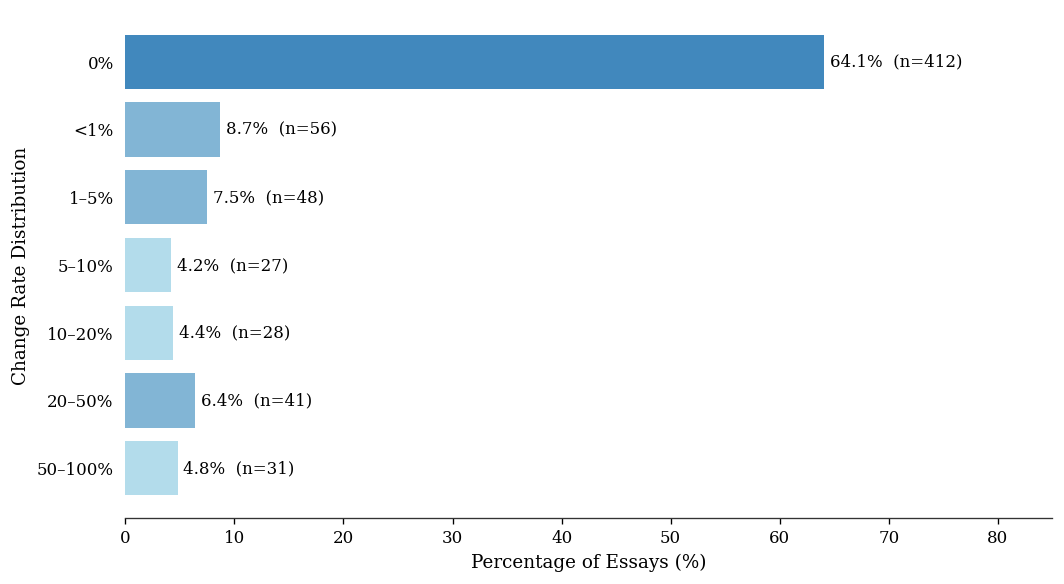

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

buckets = [
    "0%",
    "<1%",
    "1–5%",
    "5–10%",
    "10–20%",
    "20–50%",
    "50–100%"
]

# EuroLLM bucket counts and percentages from Step 3 output
counts = [412, 56, 48, 27, 28, 41, 31]
percentages = [64.1, 8.7, 7.5, 4.2, 4.4, 6.4, 4.8]

colors = ['#2c7bb6' if p > 20 else '#74add1' if p > 5 else '#abd9e9' for p in percentages]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    buckets,
    percentages,
    color=colors,
    alpha=0.9
)

ax.invert_yaxis()

for bar, pct, count in zip(bars, percentages, counts):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%  (n={count})",
        va="center",
        fontsize=10
    )

ax.set_xlabel("Percentage of Essays (%)", fontsize=11)
ax.set_ylabel("Change Rate Distribution", fontsize=11)
ax.set_xlim(0, 85)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.tick_params(left=False)
ax.xaxis.grid(False)
ax.yaxis.grid(False)

plt.tight_layout()
plt.savefig('/content/eurollm_change_rate_buckets.png', dpi=300, bbox_inches='tight')
plt.show()

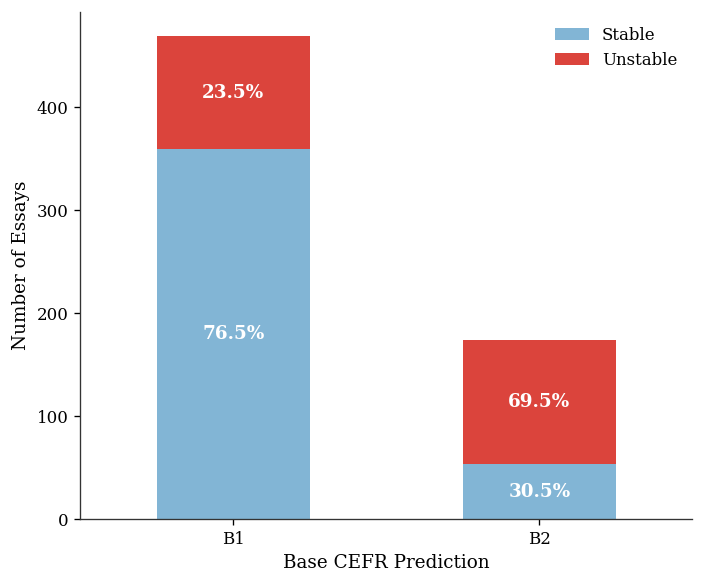

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Data
stability_data = {
    'Base Label': ['B1', 'B1', 'B2', 'B2'],
    'Status': ['Stable', 'Unstable', 'Stable', 'Unstable'],
    'Count': [359, 110, 53, 121]
}

df = pd.DataFrame(stability_data)
pivot = df.pivot(index='Base Label', columns='Status', values='Count')

fig, ax = plt.subplots(figsize=(6, 5))

pivot[['Stable', 'Unstable']].plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['#74add1', '#d73027'],
    alpha=0.9,
    width=0.5
)

# Add percentage labels
for i, (base, row) in enumerate(pivot.iterrows()):
    total = row['Stable'] + row['Unstable']
    stable_pct = row['Stable'] / total * 100
    unstable_pct = row['Unstable'] / total * 100
    ax.text(i, row['Stable'] / 2, f'{stable_pct:.1f}%',
            ha='center', va='center', fontsize=11, color='white', fontweight='bold')
    ax.text(i, row['Stable'] + row['Unstable'] / 2, f'{unstable_pct:.1f}%',
            ha='center', va='center', fontsize=11, color='white', fontweight='bold')

ax.set_xlabel('Base CEFR Prediction', fontsize=11)
ax.set_ylabel('Number of Essays', fontsize=11)
ax.set_xticklabels(['B1', 'B2'], rotation=0)
ax.legend(fontsize=10, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/eurollm_stability_by_base.png', dpi=300, bbox_inches='tight')
plt.show()